### Metric Evaluation of Trained and Saved GRU model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
import matplotlib.pyplot as plt

# Suppress warnings for clear output
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Assuming test data (X_test, y_test) and trained model saved as "best_gru_model.keras"
# Load test features and labels
X = np.load('/content/drive/MyDrive/rolling_window_sequences.npy')
metadata = pd.read_csv('/content/drive/MyDrive/sequence_metadata_with_RUL.csv')
y = metadata['RUL'].values

# Load the model
model = tf.keras.models.load_model('/content/drive/MyDrive/best_gru_model.keras')

In [ ]:
y_pred = model.predict(X)
y_pred = y_pred.flatten()

y_pred.shape

551/551 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


(17631,)

In [ ]:
# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 10.486595625571864
MAE: 7.758127409184921


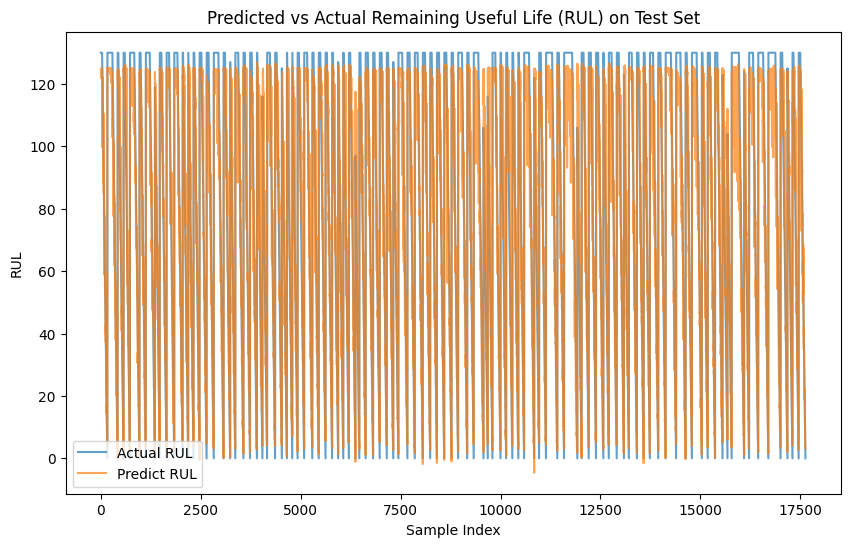

In [ ]:
# Visualize Actual vs Predict RUL
plt.figure(figsize=(10, 6))
plt.plot(y, label='Actual RUL', alpha=0.7)
plt.plot(y_pred, label='Predict RUL', alpha=0.7)
plt.title('Predicted vs Actual Remaining Useful Life (RUL) on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.show()